# **Automated Grading and Feedback**


#### Abstract

The Automated Essay and Assignment Scoring System enhances the evaluation process by leveraging Natural Language Processing (NLP) and Machine Learning to assess typed submissions with speed, accuracy, and fairness. The system evaluates assignments based on key rubric criteria such as content relevance, grammar, structure, coherence, and originality, ensuring objective and consistent grading.

The framework comprises text preprocessing , feature extraction, and assessment through multiple machine learning and Deep learning models. By automating the grading process, it significantly reduces educators' workload, minimizes subjectivity, and provides students with detailed, data-driven feedback to support academic growth. Additionally, by analyzing large volumes of text, the system enhances assessment transparency and facilitates a more efficient and scalable evaluation process, making grading smarter, faster, and more reliable in the digital age.

## Section 1: Load the Dataset

In [ ]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split

import numpy as np
import pandas as pd
from sklearn.model_selection import train_test_split, KFold
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, r2_score
from sklearn.model_selection import cross_val_score
from sklearn.utils import shuffle
from sklearn.preprocessing import StandardScaler
from scipy.stats import pearsonr
from sklearn.metrics import cohen_kappa_score

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


**Dataset**

https://drive.google.com/drive/folders/1W8TKOu9x2r0iwNgfW5rhQDiVcQYqFvAO?usp=sharing

In [ ]:
df=pd.read_csv("/content/drive/MyDrive/EssayScoringDataset/Dataset.csv")


df.head()

,score,text
0,0,I think computers are good because you can tal...
1,0,"Being active has no limit, but technology does."
2,0,Computers are good because people can find wha...
3,0,I think that computers are amazing. Computers ...
4,0,"Dear editor, computers are good for people bec..."


## Section: 2 Perform Exploratory Data Analysis (EDA)

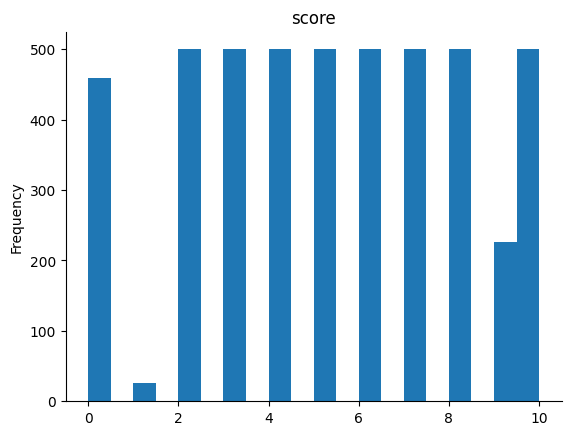

In [ ]:
from matplotlib import pyplot as plt
df['score'].plot(kind='hist', bins=20, title='score')
plt.gca().spines[['top', 'right',]].set_visible(False)

In [ ]:
df.shape

(4711, 2)

In [ ]:
df.dropna(axis=1)

,score,text
0,0,I think computers are good because you can tal...
1,0,"Being active has no limit, but technology does."
2,0,Computers are good because people can find wha...
3,0,I think that computers are amazing. Computers ...
4,0,"Dear editor, computers are good for people bec..."
...,...,...
4706,10,The features of the setting affected the cycli...
4707,10,In the essay Rough Road Ahead: Do Not Exceed ...
4708,10,The author concludes this story with the parag...
4709,10,"In the Mooring Mast, by @ORGANIZATION2, the bu..."


In [ ]:
print(df.isna().sum())

score    0
text     0
dtype: int64


In [ ]:
df.rename(columns={"text":'essay'},inplace=True)

## Section : 3 Data Training

Splitting Data into 80 20 Train Test Split


In [ ]:
from sklearn.model_selection import train_test_split
training_data, test_data = train_test_split(df, test_size=0.2, random_state=42)

# Printing the shapes of the resulting datasets
print("Shape of training data:", training_data.shape)

print("Shape of testing data:", test_data.shape)

Shape of training data: (3768, 2)
Shape of testing data: (943, 2)


In [ ]:
import re
cList = {
  "ain't": "am not","aren't": "are not","can't": "cannot","can't've": "cannot have","'cause": "because",  "could've": "could have","couldn't": "could not","couldn't've": "could not have","didn't": "did not","doesn't": "does not","don't": "do not","hadn't": "had not","hadn't've": "had not have","hasn't": "has not",
  "haven't": "have not","he'd": "he would","he'd've": "he would have","he'll": "he will","he'll've": "he will have","he's": "he is",
  "how'd": "how did","how'd'y": "how do you","how'll": "how will","how's": "how is","I'd": "I would","I'd've": "I would have","I'll": "I will","I'll've": "I will have","I'm": "I am","I've": "I have",
  "isn't": "is not","it'd": "it had","it'd've": "it would have","it'll": "it will", "it'll've": "it will have","it's": "it is","let's": "let us","ma'am": "madam","mayn't": "may not",
  "might've": "might have","mightn't": "might not","mightn't've": "might not have","must've": "must have","mustn't": "must not","mustn't've": "must not have","needn't": "need not","needn't've": "need not have","o'clock": "of the clock","oughtn't": "ought not","oughtn't've": "ought not have","shan't": "shall not","sha'n't": "shall not",
  "shan't've": "shall not have","she'd": "she would","she'd've": "she would have","she'll": "she will","she'll've": "she will have","she's": "she is",
  "should've": "should have","shouldn't": "should not","shouldn't've": "should not have","so've": "so have","so's": "so is","that'd": "that would","that'd've": "that would have","that's": "that is","there'd": "there had","there'd've": "there would have","there's": "there is","they'd": "they would","they'd've": "they would have","they'll": "they will","they'll've": "they will have","they're": "they are","they've": "they have","to've": "to have","wasn't": "was not","we'd": "we had",
  "we'd've": "we would have","we'll": "we will","we'll've": "we will have","we're": "we are","we've": "we have",
  "weren't": "were not","what'll": "what will","what'll've": "what will have",
  "what're": "what are","what's": "what is","what've": "what have","when's": "when is","when've": "when have",
  "where'd": "where did","where's": "where is","where've": "where have","who'll": "who will","who'll've": "who will have","who's": "who is","who've": "who have","why's": "why is",
  "why've": "why have","will've": "will have","won't": "will not","won't've": "will not have","would've": "would have","wouldn't": "would not",
  "wouldn't've": "would not have","y'all": "you all","y'alls": "you alls","y'all'd": "you all would",
  "y'all'd've": "you all would have","y'all're": "you all are","y'all've": "you all have","you'd": "you had","you'd've": "you would have","you'll": "you you will","you'll've": "you you will have","you're": "you are",  "you've": "you have"
   }

c_re = re.compile('(%s)' % '|'.join(cList.keys()))

def expandContractions(text, c_re=c_re):
    def replace(match):
        return cList[match.group(0)]
    return c_re.sub(replace, text)

def removeHTML(x):
    html=re.compile(r'<.*?>')
    return html.sub(r'',x)

def dataPreprocessing(x):
    x = x.lower()
    x = removeHTML(x)
    x = re.sub("@\w+", '',x)
    x = re.sub("'\d+", '',x)
    x = re.sub("\d+", '',x)
    x = re.sub("http\w+", '',x)
    x = re.sub(r"\s+", " ", x)
    x = expandContractions(x)
    x = re.sub(r"\.+", ".", x)
    x = re.sub(r"\,+", ",", x)
    x = re.sub(r'[^a-z\s]', '', x)  # Keeps only alphabetic characters and spaces

    return x


In [ ]:
training_data['essay'] = training_data['essay'].apply(dataPreprocessing)
test_data['essay'] = test_data['essay'].apply(dataPreprocessing)
print(training_data.head())

      score                                              essay
2168      5  the mood created by the author is very welcomi...
1617      4  censorship in libraries differ in certain area...
4315     10  the builders of the empire state building face...
599       2  in my opinion i believe that if the only purpo...
3386      7  there was three main obstacles the builders of...


In [ ]:
!pip install --upgrade numpy
!pip install --upgrade gensim

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 62.0/62.0 kB 3.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 16.4/16.4 MB 52.1 MB/s eta 0:00:00
  Attempting uninstall: numpy
    Found existing installation: numpy 2.0.2
    Uninstalling numpy-2.0.2:
      Successfully uninstalled numpy-2.0.2
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
tensorflow 2.18.0 requires numpy<2.1.0,>=1.26.0, but you have numpy 2.2.4 which is incompatible.
numba 0.60.0 requires numpy<2.1,>=1.22, but you have numpy 2.2.4 which is incompatible.
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 61.0/61.0 kB 2.6 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 60.6/60.6 kB 3.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 26.7/26.7 MB 61.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 18.3/18.3 MB 68.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━

In [ ]:
!pip install gensim==4.3.0



# Model Training



**Features Engineering**

1.   Average word length.
2.   Sentence count
3.   Flesch Reading Ease score
4.   Vocabulary richness (unique word count).
5.   Grammatical error count
6.   Coherence (sentence similarity).

In [ ]:
!pip install textstat

In [ ]:
import textstat


In [ ]:
from sklearn.metrics.pairwise import cosine_similarity


def get_sentence_embedding(sentence):
    words = sentence.split()
    word_vectors = [word2vec_model.wv[word] for word in words if word in word2vec_model.wv]
    return np.mean(word_vectors, axis=0) if word_vectors else np.zeros(100)

def extract_features(text):
    words = text.split()
    sentences = re.split(r'[.!?]+', text)
    sentences = [s.strip() for s in sentences if s.strip()]

    # Basic features
    essay_length = len(words)
    avg_word_length = np.mean([len(word) for word in words]) if words else 0
    sentence_count = len(sentences)
    readability_score = textstat.flesch_reading_ease(text)

    vocab_richness = len(set(words))



    if len(sentences) > 1:
        sentence_embeddings = [get_sentence_embedding(sent) for sent in sentences]
        similarities = [cosine_similarity([sentence_embeddings[i]], [sentence_embeddings[i+1]])[0][0]
                        for i in range(len(sentence_embeddings)-1)]
        coherence = np.mean(similarities) if similarities else 0
    else:
        coherence = 0

    return [essay_length, avg_word_length, sentence_count, readability_score,
            vocab_richness, coherence]




In [ ]:
X_engineered = np.array([extract_features(text) for text in df['essay']])

In [ ]:
X_engineered

array([[ 41.        ,   4.3902439 ,   3.        ,  74.49      ,
         32.        ,   0.80175459],
       [  8.        ,   5.        ,   1.        ,  46.44      ,
          8.        ,   0.        ],
       [ 23.        ,   4.39130435,   1.        ,  81.97      ,
         20.        ,   0.        ],
       ...,
       [ 88.        ,   4.82954545,   4.        ,  57.61      ,
         66.        ,   0.80449533],
       [187.        ,   4.98395722,  10.        ,  52.49      ,
        116.        ,   0.70676714],
       [134.        ,   4.61940299,   8.        ,  62.88      ,
         87.        ,   0.73963255]])

In [ ]:
X_w2v = np.array([get_average_vector(text) for text in df['essay']])



In [ ]:
X

array([[-6.75613701e-01,  7.56569922e-01,  4.58933204e-01, ...,
         7.44900000e+01,  3.20000000e+01,  8.83939862e-01],
       [-3.33585352e-01,  2.65381366e-01,  6.33807659e-01, ...,
         4.64400000e+01,  8.00000000e+00,  0.00000000e+00],
       [-6.66422248e-01,  4.48314428e-01,  9.69014704e-01, ...,
         8.19700000e+01,  2.00000000e+01,  0.00000000e+00],
       ...,
       [ 1.01769291e-01,  3.99359077e-01, -2.79957861e-01, ...,
         5.76100000e+01,  6.60000000e+01,  8.80944729e-01],
       [-1.56470791e-01,  2.57904738e-01, -4.63768423e-01, ...,
         5.24900000e+01,  1.16000000e+02,  8.41037512e-01],
       [-7.36363232e-04,  9.34065431e-02, -5.72983921e-01, ...,
         6.28800000e+01,  8.70000000e+01,  7.97292173e-01]])

In [ ]:
y

array([ 0,  0,  0, ..., 10, 10, 10])

In [ ]:
scaler = StandardScaler()
X = scaler.fit_transform(X)

**Applying Machine Learning Algorithm**

The essay scoring model, framed as a regression problem, utilizes various machine learning techniques to predict scores ranging from 0 to 10. Linear Regression, as a baseline model, provides interpretability but may struggle with capturing complex relationships in textual data. More advanced models such as Support Vector Regression (SVR) leverage kernel methods to handle non-linearity, while XGBoost, CatBoost, and LightGBM apply gradient boosting techniques to enhance predictive accuracy and handle feature interactions effectively. For text representation, the model employs Word2Vec embeddings, which capture semantic meaning by mapping words into dense vector spaces, and TF-IDF, which assigns importance to words based on their frequency across the corpus. By integrating these embedding techniques with powerful regression models, the system effectively learns to score essays with improved accuracy, leveraging both statistical and deep semantic features.

# **Section 6: Training Supervised Models on NLP-Based Features**

In [ ]:
X=X_engineered
y = df['score'].values
scaler = StandardScaler()
X = scaler.fit_transform(X)



```
# This is formatted as code
```

**Linear Regression**

In [ ]:
r2_scores, mse_scores, qwk_scores = [], [], []
model = LinearRegression()
kf = KFold(n_splits=5, shuffle=True, random_state=42)

for train_index, test_index in kf.split(X):
    X_train, X_test = X[train_index], X[test_index]
    y_train, y_test = y[train_index], y[test_index]

    model.fit(X_train, y_train)
    y_pred = model.predict(X_test)
    y_pred_rounded = np.round(y_pred)

    mse_scores.append(mean_squared_error(y_test, y_pred))
    r2_scores.append(r2_score(y_test, y_pred))
    qwk_scores.append(cohen_kappa_score(y_test, y_pred_rounded, weights="quadratic"))

print("\nResults for Linear Regression:")
print(f"Average MSE: {np.mean(mse_scores):.4f}")
print(f"Average R² Score: {np.mean(r2_scores):.4f}")
print(f"Average QWK Score: {np.mean(qwk_scores):.4f}")



Results for Linear Regression:
Average MSE: 5.6051
Average R² Score: 0.3687
Average QWK Score: 0.5391


**XGBoost**

In [ ]:
from xgboost import XGBRegressor
r2_scores, mse_scores, qwk_scores = [], [], []
model = XGBRegressor(n_estimators=100, learning_rate=0.1, random_state=42)

for train_index, test_index in kf.split(X):
    X_train, X_test = X[train_index], X[test_index]
    y_train, y_test = y[train_index], y[test_index]

    model.fit(X_train, y_train)
    y_pred = model.predict(X_test)
    y_pred_rounded = np.round(y_pred)

    mse_scores.append(mean_squared_error(y_test, y_pred))
    r2_scores.append(r2_score(y_test, y_pred))
    qwk_scores.append(cohen_kappa_score(y_test, y_pred_rounded, weights="quadratic"))

print("\nResults for XGBoost:")
print(f"Average MSE: {np.mean(mse_scores):.4f}")
print(f"Average R² Score: {np.mean(r2_scores):.4f}")
print(f"Average QWK Score: {np.mean(qwk_scores):.4f}")



Results for XGBoost:
Average MSE: 4.0324
Average R² Score: 0.5457
Average QWK Score: 0.7116


**Catboost**

In [ ]:
!pip install catboost

In [ ]:
from catboost import CatBoostRegressor
r2_scores, mse_scores, qwk_scores = [], [], []
model = CatBoostRegressor(iterations=100, depth=6, learning_rate=0.1, verbose=0, random_seed=42)

for train_index, test_index in kf.split(X):
    X_train, X_test = X[train_index], X[test_index]
    y_train, y_test = y[train_index], y[test_index]

    model.fit(X_train, y_train)
    y_pred = model.predict(X_test)
    y_pred_rounded = np.round(y_pred)

    mse_scores.append(mean_squared_error(y_test, y_pred))
    r2_scores.append(r2_score(y_test, y_pred))
    qwk_scores.append(cohen_kappa_score(y_test, y_pred_rounded, weights="quadratic"))

print("\nResults for CatBoost:")
print(f"Average MSE: {np.mean(mse_scores):.4f}")
print(f"Average R² Score: {np.mean(r2_scores):.4f}")
print(f"Average QWK Score: {np.mean(qwk_scores):.4f}")



Results for CatBoost:
Average MSE: 3.8123
Average R² Score: 0.5704
Average QWK Score: 0.7216


**SVR**

In [ ]:
from sklearn.svm import SVR
r2_scores, mse_scores, qwk_scores = [], [], []
model = SVR(kernel='rbf', C=1.0, epsilon=0.1)

for train_index, test_index in kf.split(X):
    X_train, X_test = X[train_index], X[test_index]
    y_train, y_test = y[train_index], y[test_index]

    model.fit(X_train, y_train)
    y_pred = model.predict(X_test)
    y_pred_rounded = np.round(y_pred)

    mse_scores.append(mean_squared_error(y_test, y_pred))
    r2_scores.append(r2_score(y_test, y_pred))
    qwk_scores.append(cohen_kappa_score(y_test, y_pred_rounded, weights="quadratic"))

print("\nResults for SVR:")
print(f"Average MSE: {np.mean(mse_scores):.4f}")
print(f"Average R² Score: {np.mean(r2_scores):.4f}")
print(f"Average QWK Score: {np.mean(qwk_scores):.4f}")



Results for SVR:
Average MSE: 3.8647
Average R² Score: 0.5644
Average QWK Score: 0.7267


**Lightbgm**

In [ ]:
from lightgbm import LGBMRegressor
r2_scores, mse_scores, qwk_scores = [], [], []
model = LGBMRegressor(n_estimators=100, learning_rate=0.1, random_state=42)

for train_index, test_index in kf.split(X):
    X_train, X_test = X[train_index], X[test_index]
    y_train, y_test = y[train_index], y[test_index]

    model.fit(X_train, y_train)
    y_pred = model.predict(X_test)
    y_pred_rounded = np.round(y_pred)

    mse_scores.append(mean_squared_error(y_test, y_pred))
    r2_scores.append(r2_score(y_test, y_pred))
    qwk_scores.append(cohen_kappa_score(y_test, y_pred_rounded, weights="quadratic"))

print("\nResults for LightGBM:")
print(f"Average MSE: {np.mean(mse_scores):.4f}")
print(f"Average R² Score: {np.mean(r2_scores):.4f}")
print(f"Average QWK Score: {np.mean(qwk_scores):.4f}")


/usr/local/lib/python3.11/dist-packages/lightgbm/sklearn.py:865: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.
  _X, _y = _LGBMCheckXY(X, y, accept_sparse=True, force_all_finite=False, ensure_min_samples=2)


[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.000382 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 1338
[LightGBM] [Info] Number of data points in the train set: 3768, number of used features: 6
[LightGBM] [Info] Start training from score 5.234873


/usr/local/lib/python3.11/dist-packages/lightgbm/sklearn.py:1007: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.
  X = _LGBMCheckArray(X, accept_sparse=True, force_all_finite=False)
/usr/local/lib/python3.11/dist-packages/lightgbm/sklearn.py:865: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.
  _X, _y = _LGBMCheckXY(X, y, accept_sparse=True, force_all_finite=False, ensure_min_samples=2)


[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.000352 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 1335
[LightGBM] [Info] Number of data points in the train set: 3769, number of used features: 6
[LightGBM] [Info] Start training from score 5.208013


/usr/local/lib/python3.11/dist-packages/lightgbm/sklearn.py:1007: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.
  X = _LGBMCheckArray(X, accept_sparse=True, force_all_finite=False)
/usr/local/lib/python3.11/dist-packages/lightgbm/sklearn.py:865: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.
  _X, _y = _LGBMCheckXY(X, y, accept_sparse=True, force_all_finite=False, ensure_min_samples=2)


[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.000347 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 1338
[LightGBM] [Info] Number of data points in the train set: 3769, number of used features: 6
[LightGBM] [Info] Start training from score 5.208013


/usr/local/lib/python3.11/dist-packages/lightgbm/sklearn.py:1007: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.
  X = _LGBMCheckArray(X, accept_sparse=True, force_all_finite=False)
/usr/local/lib/python3.11/dist-packages/lightgbm/sklearn.py:865: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.
  _X, _y = _LGBMCheckXY(X, y, accept_sparse=True, force_all_finite=False, ensure_min_samples=2)


[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.010372 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 1336
[LightGBM] [Info] Number of data points in the train set: 3769, number of used features: 6
[LightGBM] [Info] Start training from score 5.206155
[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.000366 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 1338
[LightGBM] [Info] Number of data points in the train set: 3769, number of used features: 6
[LightGBM] [Info] Start training from score 5.209605

Results for LightGBM:
Average MSE: 4.0047
Average R² Score: 0.5488
Average QWK Score: 0.7144


/usr/local/lib/python3.11/dist-packages/lightgbm/sklearn.py:1007: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.
  X = _LGBMCheckArray(X, accept_sparse=True, force_all_finite=False)
/usr/local/lib/python3.11/dist-packages/lightgbm/sklearn.py:865: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.
  _X, _y = _LGBMCheckXY(X, y, accept_sparse=True, force_all_finite=False, ensure_min_samples=2)
/usr/local/lib/python3.11/dist-packages/lightgbm/sklearn.py:1007: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.
  X = _LGBMCheckArray(X, accept_sparse=True, force_all_finite=False)


# **Section : Training Models on TFIDF,WordtoVec**

# **Embedding : WordToVec**

In [ ]:
import gensim
sentences = [essay.split() for essay in training_data['essay']]
word2vec_model = gensim.models.Word2Vec(sentences, vector_size=100, window=5, min_count=1, workers=4)

def get_average_vector(text):
    words = text.split()
    word_vectors = [word2vec_model.wv[word] for word in words if word in word2vec_model.wv]
    return np.mean(word_vectors, axis=0) if word_vectors else np.zeros(100)  # Handle empty cases






Word2Vec is a popular word embedding technique introduced by Mikolov et al. (2013) at Google. It represents words in a high-dimensional vector space where semantically similar words have similar vector representations. Word2Vec helps in capturing the contextual meaning of words, allowing machines to process and understand natural language more effectively.

How Word2Vec Works
Word2Vec uses a neural network-based approach to learn vector representations of words from a large corpus. The model trains in an unsupervised manner and generates dense, continuous, and distributed representations of words.

There are two main architectures of Word2Vec:

**Continuous Bag of Words (CBOW)**

Predicts the target word using the surrounding context words.
Works well for smaller datasets and generalizes better.
Faster training time.

**Skip-Gram Model**

Predicts the surrounding context words given a target word.
Works well with large datasets and captures rare words better.
Slower training but produces high-quality embeddings.


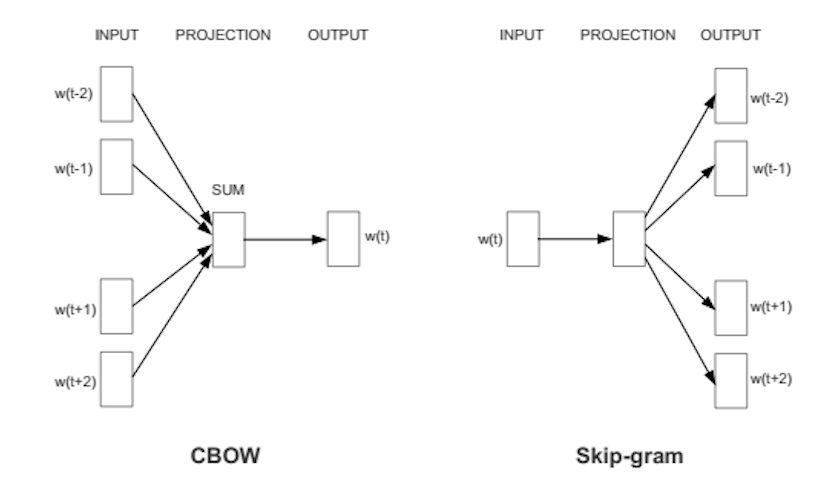

In [ ]:
X_w2v = np.array([get_average_vector(text) for text in df['essay']])
X=X_w2v
y = df['score'].values
scaler = StandardScaler()
X = scaler.fit_transform(X)



**Model 1 : Linear Regression + Word2Vec**

In [ ]:
r2_scores, mse_scores, qwk_scores = [], [], []
model = LinearRegression()
kf = KFold(n_splits=5, shuffle=True, random_state=42)

for train_index, test_index in kf.split(X):
    X_train, X_test = X[train_index], X[test_index]
    y_train, y_test = y[train_index], y[test_index]

    model.fit(X_train, y_train)
    y_pred = model.predict(X_test)
    y_pred_rounded = np.round(y_pred)

    mse_scores.append(mean_squared_error(y_test, y_pred))
    r2_scores.append(r2_score(y_test, y_pred))
    qwk_scores.append(cohen_kappa_score(y_test, y_pred_rounded, weights="quadratic"))

print("\nResults for Linear Regression:")
print(f"Average MSE: {np.mean(mse_scores):.4f}")
print(f"Average R² Score: {np.mean(r2_scores):.4f}")
print(f"Average QWK Score: {np.mean(qwk_scores):.4f}")



Results for Linear Regression:
Average MSE: 5.7211
Average R² Score: 0.3558
Average QWK Score: 0.5387


**Model 2 : XGboost + Word2Vec**

In [ ]:
from xgboost import XGBRegressor
r2_scores, mse_scores, qwk_scores = [], [], []
model = XGBRegressor(n_estimators=100, learning_rate=0.1, random_state=42)

for train_index, test_index in kf.split(X):
    X_train, X_test = X[train_index], X[test_index]
    y_train, y_test = y[train_index], y[test_index]

    model.fit(X_train, y_train)
    y_pred = model.predict(X_test)
    y_pred_rounded = np.round(y_pred)

    mse_scores.append(mean_squared_error(y_test, y_pred))
    r2_scores.append(r2_score(y_test, y_pred))
    qwk_scores.append(cohen_kappa_score(y_test, y_pred_rounded, weights="quadratic"))

print("\nResults for XGBoost:")
print(f"Average MSE: {np.mean(mse_scores):.4f}")
print(f"Average R² Score: {np.mean(r2_scores):.4f}")
print(f"Average QWK Score: {np.mean(qwk_scores):.4f}")



Results for XGBoost:
Average MSE: 4.0142
Average R² Score: 0.5476
Average QWK Score: 0.6981


**Model 3 : CatBoost + Word2Vec**


In [ ]:
from catboost import CatBoostRegressor
r2_scores, mse_scores, qwk_scores = [], [], []
model = CatBoostRegressor(iterations=100, depth=6, learning_rate=0.1, verbose=0, random_seed=42)

for train_index, test_index in kf.split(X):
    X_train, X_test = X[train_index], X[test_index]
    y_train, y_test = y[train_index], y[test_index]

    model.fit(X_train, y_train)
    y_pred = model.predict(X_test)
    y_pred_rounded = np.round(y_pred)

    mse_scores.append(mean_squared_error(y_test, y_pred))
    r2_scores.append(r2_score(y_test, y_pred))
    qwk_scores.append(cohen_kappa_score(y_test, y_pred_rounded, weights="quadratic"))

print("\nResults for CatBoost:")
print(f"Average MSE: {np.mean(mse_scores):.4f}")
print(f"Average R² Score: {np.mean(r2_scores):.4f}")
print(f"Average QWK Score: {np.mean(qwk_scores):.4f}")



Results for CatBoost:
Average MSE: 4.1685
Average R² Score: 0.5303
Average QWK Score: 0.6726


**Model 4 :Support Vector Regression + WordtoVec**

In [ ]:
from sklearn.svm import SVR
r2_scores, mse_scores, qwk_scores = [], [], []
model = SVR(kernel='rbf', C=1.0, epsilon=0.1)

for train_index, test_index in kf.split(X):
    X_train, X_test = X[train_index], X[test_index]
    y_train, y_test = y[train_index], y[test_index]

    model.fit(X_train, y_train)
    y_pred = model.predict(X_test)
    y_pred_rounded = np.round(y_pred)

    mse_scores.append(mean_squared_error(y_test, y_pred))
    r2_scores.append(r2_score(y_test, y_pred))
    qwk_scores.append(cohen_kappa_score(y_test, y_pred_rounded, weights="quadratic"))

print("\nResults for SVR:")
print(f"Average MSE: {np.mean(mse_scores):.4f}")
print(f"Average R² Score: {np.mean(r2_scores):.4f}")
print(f"Average QWK Score: {np.mean(qwk_scores):.4f}")



Results for SVR:
Average MSE: 3.8385
Average R² Score: 0.5677
Average QWK Score: 0.7118


**Model 5: LightGBM + Word2Vec**

In [ ]:
!pip install lightgbm

In [ ]:
from lightgbm import LGBMRegressor
r2_scores, mse_scores, qwk_scores = [], [], []
model = LGBMRegressor(n_estimators=100, learning_rate=0.1, random_state=42)

for train_index, test_index in kf.split(X):
    X_train, X_test = X[train_index], X[test_index]
    y_train, y_test = y[train_index], y[test_index]

    model.fit(X_train, y_train)
    y_pred = model.predict(X_test)
    y_pred_rounded = np.round(y_pred)

    mse_scores.append(mean_squared_error(y_test, y_pred))
    r2_scores.append(r2_score(y_test, y_pred))
    qwk_scores.append(cohen_kappa_score(y_test, y_pred_rounded, weights="quadratic"))

print("\nResults for LightGBM:")
print(f"Average MSE: {np.mean(mse_scores):.4f}")
print(f"Average R² Score: {np.mean(r2_scores):.4f}")
print(f"Average QWK Score: {np.mean(qwk_scores):.4f}")


[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.004725 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 25500
[LightGBM] [Info] Number of data points in the train set: 3768, number of used features: 100
[LightGBM] [Info] Start training from score 5.234873


/usr/local/lib/python3.11/dist-packages/lightgbm/sklearn.py:865: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.
  _X, _y = _LGBMCheckXY(X, y, accept_sparse=True, force_all_finite=False, ensure_min_samples=2)
/usr/local/lib/python3.11/dist-packages/lightgbm/sklearn.py:1007: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.
  X = _LGBMCheckArray(X, accept_sparse=True, force_all_finite=False)
/usr/local/lib/python3.11/dist-packages/lightgbm/sklearn.py:865: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.
  _X, _y = _LGBMCheckXY(X, y, accept_sparse=True, force_all_finite=False, ensure_min_samples=2)


[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.006252 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 25500
[LightGBM] [Info] Number of data points in the train set: 3769, number of used features: 100
[LightGBM] [Info] Start training from score 5.208013


/usr/local/lib/python3.11/dist-packages/lightgbm/sklearn.py:1007: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.
  X = _LGBMCheckArray(X, accept_sparse=True, force_all_finite=False)
/usr/local/lib/python3.11/dist-packages/lightgbm/sklearn.py:865: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.
  _X, _y = _LGBMCheckXY(X, y, accept_sparse=True, force_all_finite=False, ensure_min_samples=2)


[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.006545 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 25500
[LightGBM] [Info] Number of data points in the train set: 3769, number of used features: 100
[LightGBM] [Info] Start training from score 5.208013


/usr/local/lib/python3.11/dist-packages/lightgbm/sklearn.py:1007: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.
  X = _LGBMCheckArray(X, accept_sparse=True, force_all_finite=False)
/usr/local/lib/python3.11/dist-packages/lightgbm/sklearn.py:865: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.
  _X, _y = _LGBMCheckXY(X, y, accept_sparse=True, force_all_finite=False, ensure_min_samples=2)


[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.003728 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 25500
[LightGBM] [Info] Number of data points in the train set: 3769, number of used features: 100
[LightGBM] [Info] Start training from score 5.206155


/usr/local/lib/python3.11/dist-packages/lightgbm/sklearn.py:1007: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.
  X = _LGBMCheckArray(X, accept_sparse=True, force_all_finite=False)
/usr/local/lib/python3.11/dist-packages/lightgbm/sklearn.py:865: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.
  _X, _y = _LGBMCheckXY(X, y, accept_sparse=True, force_all_finite=False, ensure_min_samples=2)


[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.003636 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 25500
[LightGBM] [Info] Number of data points in the train set: 3769, number of used features: 100
[LightGBM] [Info] Start training from score 5.209605

Results for LightGBM:
Average MSE: 3.9207
Average R² Score: 0.5584
Average QWK Score: 0.7091


/usr/local/lib/python3.11/dist-packages/lightgbm/sklearn.py:1007: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.
  X = _LGBMCheckArray(X, accept_sparse=True, force_all_finite=False)


**Word Embedding Technique 2 : TF-IDF**

In [ ]:
import numpy as np
from sklearn.feature_extraction.text import TfidfVectorizer
tfidf_vectorizer = TfidfVectorizer(max_features=10000)
tfidf_matrix = tfidf_vectorizer.fit_transform(df['essay'])
X_tfidf = tfidf_matrix.toarray()

X = X_tfidf
y = df['score'].values


In [ ]:
y

array([ 0,  0,  0, ..., 10, 10, 10])

In [ ]:
X

array([[  0.        ,   0.        ,   0.        , ...,  74.49      ,
         32.        ,   0.88393986],
       [  0.        ,   0.        ,   0.        , ...,  46.44      ,
          8.        ,   0.        ],
       [  0.        ,   0.        ,   0.        , ...,  81.97      ,
         20.        ,   0.        ],
       ...,
       [  0.        ,   0.        ,   0.        , ...,  57.61      ,
         66.        ,   0.88094473],
       [  0.        ,   0.        ,   0.        , ...,  52.49      ,
        116.        ,   0.84103751],
       [  0.        ,   0.        ,   0.        , ...,  62.88      ,
         87.        ,   0.79729217]])

In [ ]:
scaler = StandardScaler()
X = scaler.fit_transform(X)

**Model 6: Linear Regression + TFIDF**

In [ ]:
r2_scores, mse_scores, qwk_scores = [], [], []
model = LinearRegression()
kf = KFold(n_splits=5, shuffle=True, random_state=42)

for train_index, test_index in kf.split(X):
    X_train, X_test = X[train_index], X[test_index]
    y_train, y_test = y[train_index], y[test_index]

    model.fit(X_train, y_train)
    y_pred = model.predict(X_test)
    y_pred_rounded = np.round(y_pred)

    mse_scores.append(mean_squared_error(y_test, y_pred))
    r2_scores.append(r2_score(y_test, y_pred))
    qwk_scores.append(cohen_kappa_score(y_test, y_pred_rounded, weights="quadratic"))

print("\nResults for Linear Regression:")
print(f"Average MSE: {np.mean(mse_scores):.4f}")
print(f"Average R² Score: {np.mean(r2_scores):.4f}")
print(f"Average QWK Score: {np.mean(qwk_scores):.4f}")



Results for Linear Regression:
Average MSE: 7.0813
Average R² Score: 0.2012
Average QWK Score: 0.6436


**Model 7: XGBBoost + TFIDF**

In [ ]:
from xgboost import XGBRegressor
r2_scores, mse_scores, qwk_scores = [], [], []
model = XGBRegressor(n_estimators=100, learning_rate=0.1, random_state=42)

for train_index, test_index in kf.split(X):
    X_train, X_test = X[train_index], X[test_index]
    y_train, y_test = y[train_index], y[test_index]

    model.fit(X_train, y_train)
    y_pred = model.predict(X_test)
    y_pred_rounded = np.round(y_pred)

    mse_scores.append(mean_squared_error(y_test, y_pred))
    r2_scores.append(r2_score(y_test, y_pred))
    qwk_scores.append(cohen_kappa_score(y_test, y_pred_rounded, weights="quadratic"))


print("\nResults for XGBoost:")
print(f"Average MSE: {np.mean(mse_scores):.4f}")
print(f"Average R² Score: {np.mean(r2_scores):.4f}")
print(f"Average QWK Score: {np.mean(qwk_scores):.4f}")



Results for XGBoost:
Average MSE: 2.4433
Average R² Score: 0.7250
Average QWK Score: 0.8309


**Model 8: CatBoost + TFIDF**

In [ ]:
from catboost import CatBoostRegressor
r2_scores, mse_scores, qwk_scores = [], [], []
model = CatBoostRegressor(iterations=100, depth=6, learning_rate=0.1, verbose=0, random_seed=42)

for train_index, test_index in kf.split(X):
    X_train, X_test = X[train_index], X[test_index]
    y_train, y_test = y[train_index], y[test_index]

    model.fit(X_train, y_train)
    y_pred = model.predict(X_test)
    y_pred_rounded = np.round(y_pred)

    mse_scores.append(mean_squared_error(y_test, y_pred))
    r2_scores.append(r2_score(y_test, y_pred))
    qwk_scores.append(cohen_kappa_score(y_test, y_pred_rounded, weights="quadratic"))

print("\nResults for CatBoost:")
print(f"Average MSE: {np.mean(mse_scores):.4f}")
print(f"Average R² Score: {np.mean(r2_scores):.4f}")
print(f"Average QWK Score: {np.mean(qwk_scores):.4f}")



Results for CatBoost:
Average MSE: 2.5702
Average R² Score: 0.7106
Average QWK Score: 0.8189


**Model 9 : Support Vector Regressor + TFIDF**

In [ ]:
from sklearn.svm import SVR
r2_scores, mse_scores, qwk_scores = [], [], []
model = SVR(kernel='rbf', C=1.0, epsilon=0.1)

for train_index, test_index in kf.split(X):
    X_train, X_test = X[train_index], X[test_index]
    y_train, y_test = y[train_index], y[test_index]

    model.fit(X_train, y_train)
    y_pred = model.predict(X_test)
    y_pred_rounded = np.round(y_pred)

    mse_scores.append(mean_squared_error(y_test, y_pred))
    r2_scores.append(r2_score(y_test, y_pred))
    qwk_scores.append(cohen_kappa_score(y_test, y_pred_rounded, weights="quadratic"))

print("\nResults for SVR:")
print(f"Average MSE: {np.mean(mse_scores):.4f}")
print(f"Average R² Score: {np.mean(r2_scores):.4f}")
print(f"Average QWK Score: {np.mean(qwk_scores):.4f}")


Results for SVR:
Average MSE: 4.1605
Average R² Score: 0.5313
Average QWK Score: 0.6906


**Model 10 : LGBMRegressor+TFIDF**

In [ ]:
from lightgbm import LGBMRegressor
r2_scores, mse_scores, qwk_scores = [], [], []
model = LGBMRegressor(n_estimators=100, learning_rate=0.1, random_state=42)

for train_index, test_index in kf.split(X):
    X_train, X_test = X[train_index], X[test_index]
    y_train, y_test = y[train_index], y[test_index]

    model.fit(X_train, y_train)
    y_pred = model.predict(X_test)
    y_pred_rounded = np.round(y_pred)

    mse_scores.append(mean_squared_error(y_test, y_pred))
    r2_scores.append(r2_score(y_test, y_pred))
    qwk_scores.append(cohen_kappa_score(y_test, y_pred_rounded, weights="quadratic"))

print("\nResults for LightGBM:")
print(f"Average MSE: {np.mean(mse_scores):.4f}")
print(f"Average R² Score: {np.mean(r2_scores):.4f}")
print(f"Average QWK Score: {np.mean(qwk_scores):.4f}")


/usr/local/lib/python3.11/dist-packages/lightgbm/sklearn.py:865: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.
  _X, _y = _LGBMCheckXY(X, y, accept_sparse=True, force_all_finite=False, ensure_min_samples=2)


[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.064471 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 97632
[LightGBM] [Info] Number of data points in the train set: 3768, number of used features: 2107
[LightGBM] [Info] Start training from score 5.234873


/usr/local/lib/python3.11/dist-packages/lightgbm/sklearn.py:1007: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.
  X = _LGBMCheckArray(X, accept_sparse=True, force_all_finite=False)
/usr/local/lib/python3.11/dist-packages/lightgbm/sklearn.py:865: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.
  _X, _y = _LGBMCheckXY(X, y, accept_sparse=True, force_all_finite=False, ensure_min_samples=2)


[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.135258 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 96677
[LightGBM] [Info] Number of data points in the train set: 3769, number of used features: 2075
[LightGBM] [Info] Start training from score 5.208013


/usr/local/lib/python3.11/dist-packages/lightgbm/sklearn.py:1007: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.
  X = _LGBMCheckArray(X, accept_sparse=True, force_all_finite=False)
/usr/local/lib/python3.11/dist-packages/lightgbm/sklearn.py:865: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.
  _X, _y = _LGBMCheckXY(X, y, accept_sparse=True, force_all_finite=False, ensure_min_samples=2)


...

/usr/local/lib/python3.11/dist-packages/lightgbm/sklearn.py:1007: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.
  X = _LGBMCheckArray(X, accept_sparse=True, force_all_finite=False)
/usr/local/lib/python3.11/dist-packages/lightgbm/sklearn.py:865: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.
  _X, _y = _LGBMCheckXY(X, y, accept_sparse=True, force_all_finite=False, ensure_min_samples=2)


[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.075569 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 96851
[LightGBM] [Info] Number of data points in the train set: 3769, number of used features: 2078
[LightGBM] [Info] Start training from score 5.206155


/usr/local/lib/python3.11/dist-packages/lightgbm/sklearn.py:1007: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.
  X = _LGBMCheckArray(X, accept_sparse=True, force_all_finite=False)
/usr/local/lib/python3.11/dist-packages/lightgbm/sklearn.py:865: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.
  _X, _y = _LGBMCheckXY(X, y, accept_sparse=True, force_all_finite=False, ensure_min_samples=2)


[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.110314 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 97581
[LightGBM] [Info] Number of data points in the train set: 3769, number of used features: 2089
[LightGBM] [Info] Start training from score 5.209605

Results for LightGBM:
Average MSE: 2.7001
Average R² Score: 0.6961
Average QWK Score: 0.8115


/usr/local/lib/python3.11/dist-packages/lightgbm/sklearn.py:1007: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.
  X = _LGBMCheckArray(X, accept_sparse=True, force_all_finite=False)


In [ ]:
save best model

# **Section Training Model on Combination**

In [ ]:

X = np.hstack((X_w2v, X_engineered))
y = df['score'].values
scaler = StandardScaler()
X = scaler.fit_transform(X)

**Model 1 : Linear Regression + Word2Vec +Feature Engineering**

In [ ]:
r2_scores, mse_scores, qwk_scores = [], [], []
model = LinearRegression()
kf = KFold(n_splits=5, shuffle=True, random_state=42)

for train_index, test_index in kf.split(X):
    X_train, X_test = X[train_index], X[test_index]
    y_train, y_test = y[train_index], y[test_index]

    model.fit(X_train, y_train)
    y_pred = model.predict(X_test)
    y_pred_rounded = np.round(y_pred)

    mse_scores.append(mean_squared_error(y_test, y_pred))
    r2_scores.append(r2_score(y_test, y_pred))
    qwk_scores.append(cohen_kappa_score(y_test, y_pred_rounded, weights="quadratic"))

print("\nResults for Linear Regression:")
print(f"Average MSE: {np.mean(mse_scores):.4f}")
print(f"Average R² Score: {np.mean(r2_scores):.4f}")
print(f"Average QWK Score: {np.mean(qwk_scores):.4f}")



Results for Linear Regression:
Average MSE: 5.6051
Average R² Score: 0.3687
Average QWK Score: 0.5391


**Model 2 :XGBRegressor+ Word2Vec+Feature Engineering**

In [ ]:
from xgboost import XGBRegressor
r2_scores, mse_scores, qwk_scores = [], [], []
model = XGBRegressor(n_estimators=100, learning_rate=0.1, random_state=42)

for train_index, test_index in kf.split(X):
    X_train, X_test = X[train_index], X[test_index]
    y_train, y_test = y[train_index], y[test_index]

    model.fit(X_train, y_train)
    y_pred = model.predict(X_test)
    y_pred_rounded = np.round(y_pred)

    mse_scores.append(mean_squared_error(y_test, y_pred))
    r2_scores.append(r2_score(y_test, y_pred))
    qwk_scores.append(cohen_kappa_score(y_test, y_pred_rounded, weights="quadratic"))

print("\nResults for XGBoost:")
print(f"Average MSE: {np.mean(mse_scores):.4f}")
print(f"Average R² Score: {np.mean(r2_scores):.4f}")
print(f"Average QWK Score: {np.mean(qwk_scores):.4f}")



Results for XGBoost:
Average MSE: 4.0324
Average R² Score: 0.5457
Average QWK Score: 0.7116


**Model 3 : CatBoost + Word2Vec +Feature Engineering**


In [ ]:
from catboost import CatBoostRegressor
r2_scores, mse_scores, qwk_scores = [], [], []
model = CatBoostRegressor(iterations=100, depth=6, learning_rate=0.1, verbose=0, random_seed=42)

for train_index, test_index in kf.split(X):
    X_train, X_test = X[train_index], X[test_index]
    y_train, y_test = y[train_index], y[test_index]

    model.fit(X_train, y_train)
    y_pred = model.predict(X_test)
    y_pred_rounded = np.round(y_pred)

    mse_scores.append(mean_squared_error(y_test, y_pred))
    r2_scores.append(r2_score(y_test, y_pred))
    qwk_scores.append(cohen_kappa_score(y_test, y_pred_rounded, weights="quadratic"))

print("\nResults for CatBoost:")
print(f"Average MSE: {np.mean(mse_scores):.4f}")
print(f"Average R² Score: {np.mean(r2_scores):.4f}")
print(f"Average QWK Score: {np.mean(qwk_scores):.4f}")



Results for CatBoost:
Average MSE: 2.4846
Average R² Score: 0.7204
Average QWK Score: 0.8325


**Model 4 :Support Vector Regression + WordtoVec +Feature Engineering**

In [ ]:
from sklearn.svm import SVR
r2_scores, mse_scores, qwk_scores = [], [], []
model = SVR(kernel='rbf', C=1.0, epsilon=0.1)

for train_index, test_index in kf.split(X):
    X_train, X_test = X[train_index], X[test_index]
    y_train, y_test = y[train_index], y[test_index]

    model.fit(X_train, y_train)
    y_pred = model.predict(X_test)
    y_pred_rounded = np.round(y_pred)

    mse_scores.append(mean_squared_error(y_test, y_pred))
    r2_scores.append(r2_score(y_test, y_pred))
    qwk_scores.append(cohen_kappa_score(y_test, y_pred_rounded, weights="quadratic"))

print("\nResults for SVR:")
print(f"Average MSE: {np.mean(mse_scores):.4f}")
print(f"Average R² Score: {np.mean(r2_scores):.4f}")
print(f"Average QWK Score: {np.mean(qwk_scores):.4f}")



Results for SVR:
Average MSE: 2.8552
Average R² Score: 0.6783
Average QWK Score: 0.7977


**Model 5: LightGBM + Word2Vec+Feature Engineering**

In [ ]:
!pip install lightgbm

In [ ]:
from lightgbm import LGBMRegressor
r2_scores, mse_scores, qwk_scores = [], [], []
model = LGBMRegressor(n_estimators=100, learning_rate=0.1, random_state=42)

for train_index, test_index in kf.split(X):
    X_train, X_test = X[train_index], X[test_index]
    y_train, y_test = y[train_index], y[test_index]

    model.fit(X_train, y_train)
    y_pred = model.predict(X_test)
    y_pred_rounded = np.round(y_pred)

    mse_scores.append(mean_squared_error(y_test, y_pred))
    r2_scores.append(r2_score(y_test, y_pred))
    qwk_scores.append(cohen_kappa_score(y_test, y_pred_rounded, weights="quadratic"))

print("\nResults for LightGBM:")
print(f"Average MSE: {np.mean(mse_scores):.4f}")
print(f"Average R² Score: {np.mean(r2_scores):.4f}")
print(f"Average QWK Score: {np.mean(qwk_scores):.4f}")


/usr/local/lib/python3.11/dist-packages/lightgbm/sklearn.py:865: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.
  _X, _y = _LGBMCheckXY(X, y, accept_sparse=True, force_all_finite=False, ensure_min_samples=2)


[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.010108 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 26838
[LightGBM] [Info] Number of data points in the train set: 3768, number of used features: 106
[LightGBM] [Info] Start training from score 5.234873


/usr/local/lib/python3.11/dist-packages/lightgbm/sklearn.py:1007: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.
  X = _LGBMCheckArray(X, accept_sparse=True, force_all_finite=False)
/usr/local/lib/python3.11/dist-packages/lightgbm/sklearn.py:865: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.
  _X, _y = _LGBMCheckXY(X, y, accept_sparse=True, force_all_finite=False, ensure_min_samples=2)


[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.007861 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 26835
[LightGBM] [Info] Number of data points in the train set: 3769, number of used features: 106
[LightGBM] [Info] Start training from score 5.208013


/usr/local/lib/python3.11/dist-packages/lightgbm/sklearn.py:1007: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.
  X = _LGBMCheckArray(X, accept_sparse=True, force_all_finite=False)
/usr/local/lib/python3.11/dist-packages/lightgbm/sklearn.py:865: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.
  _X, _y = _LGBMCheckXY(X, y, accept_sparse=True, force_all_finite=False, ensure_min_samples=2)


...

/usr/local/lib/python3.11/dist-packages/lightgbm/sklearn.py:1007: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.
  X = _LGBMCheckArray(X, accept_sparse=True, force_all_finite=False)
/usr/local/lib/python3.11/dist-packages/lightgbm/sklearn.py:865: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.
  _X, _y = _LGBMCheckXY(X, y, accept_sparse=True, force_all_finite=False, ensure_min_samples=2)


[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.008992 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 26836
[LightGBM] [Info] Number of data points in the train set: 3769, number of used features: 106
[LightGBM] [Info] Start training from score 5.206155


/usr/local/lib/python3.11/dist-packages/lightgbm/sklearn.py:1007: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.
  X = _LGBMCheckArray(X, accept_sparse=True, force_all_finite=False)
/usr/local/lib/python3.11/dist-packages/lightgbm/sklearn.py:865: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.
  _X, _y = _LGBMCheckXY(X, y, accept_sparse=True, force_all_finite=False, ensure_min_samples=2)


[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.007172 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 26838
[LightGBM] [Info] Number of data points in the train set: 3769, number of used features: 106
[LightGBM] [Info] Start training from score 5.209605

Results for LightGBM:
Average MSE: 2.4549
Average R² Score: 0.7238
Average QWK Score: 0.8376


/usr/local/lib/python3.11/dist-packages/lightgbm/sklearn.py:1007: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.
  X = _LGBMCheckArray(X, accept_sparse=True, force_all_finite=False)


**Word Embedding Technique 2 : TF-IDF**

In [ ]:
import numpy as np
from sklearn.feature_extraction.text import TfidfVectorizer
tfidf_vectorizer = TfidfVectorizer(max_features=10000)
tfidf_matrix = tfidf_vectorizer.fit_transform(df['essay'])
X_tfidf = tfidf_matrix.toarray()

X = np.hstack((X_tfidf, X_engineered))
y = df['score'].values


In [ ]:
y

array([ 0,  0,  0, ..., 10, 10, 10])

In [ ]:
X

array([[  0.        ,   0.        ,   0.        , ...,  74.49      ,
         32.        ,   0.88393986],
       [  0.        ,   0.        ,   0.        , ...,  46.44      ,
          8.        ,   0.        ],
       [  0.        ,   0.        ,   0.        , ...,  81.97      ,
         20.        ,   0.        ],
       ...,
       [  0.        ,   0.        ,   0.        , ...,  57.61      ,
         66.        ,   0.88094473],
       [  0.        ,   0.        ,   0.        , ...,  52.49      ,
        116.        ,   0.84103751],
       [  0.        ,   0.        ,   0.        , ...,  62.88      ,
         87.        ,   0.79729217]])

In [ ]:
scaler = StandardScaler()
X = scaler.fit_transform(X)

**Model 6: Linear Regression + TFIDF +Feature Engineering**

In [ ]:
r2_scores, mse_scores, qwk_scores = [], [], []
model = LinearRegression()
kf = KFold(n_splits=5, shuffle=True, random_state=42)

for train_index, test_index in kf.split(X):
    X_train, X_test = X[train_index], X[test_index]
    y_train, y_test = y[train_index], y[test_index]

    model.fit(X_train, y_train)
    y_pred = model.predict(X_test)
    y_pred_rounded = np.round(y_pred)

    mse_scores.append(mean_squared_error(y_test, y_pred))
    r2_scores.append(r2_score(y_test, y_pred))
    qwk_scores.append(cohen_kappa_score(y_test, y_pred_rounded, weights="quadratic"))

print("\nResults for Linear Regression:")
print(f"Average MSE: {np.mean(mse_scores):.4f}")
print(f"Average R² Score: {np.mean(r2_scores):.4f}")
print(f"Average QWK Score: {np.mean(qwk_scores):.4f}")



Results for Linear Regression:
Average MSE: 5.4707
Average R² Score: 0.3833
Average QWK Score: 0.6860


**Model 7: XGBBoost + TFIDF +Feature Engineering**

In [ ]:
from xgboost import XGBRegressor
r2_scores, mse_scores, qwk_scores = [], [], []
model = XGBRegressor(n_estimators=100, learning_rate=0.1, random_state=42)

for train_index, test_index in kf.split(X):
    X_train, X_test = X[train_index], X[test_index]
    y_train, y_test = y[train_index], y[test_index]

    model.fit(X_train, y_train)
    y_pred = model.predict(X_test)
    y_pred_rounded = np.round(y_pred)

    mse_scores.append(mean_squared_error(y_test, y_pred))
    r2_scores.append(r2_score(y_test, y_pred))
    qwk_scores.append(cohen_kappa_score(y_test, y_pred_rounded, weights="quadratic"))

print("\nResults for XGBoost:")
print(f"Average MSE: {np.mean(mse_scores):.4f}")
print(f"Average R² Score: {np.mean(r2_scores):.4f}")
print(f"Average QWK Score: {np.mean(qwk_scores):.4f}")



Results for XGBoost:
Average MSE: 2.4257
Average R² Score: 0.7270
Average QWK Score: 0.8351


**Model 8: CatBoost + TFIDF +Feature Engineering**

In [ ]:
from catboost import CatBoostRegressor
r2_scores, mse_scores, qwk_scores = [], [], []
model = CatBoostRegressor(iterations=100, depth=6, learning_rate=0.1, verbose=0, random_seed=42)

for train_index, test_index in kf.split(X):
    X_train, X_test = X[train_index], X[test_index]
    y_train, y_test = y[train_index], y[test_index]

    model.fit(X_train, y_train)
    y_pred = model.predict(X_test)
    y_pred_rounded = np.round(y_pred)

    mse_scores.append(mean_squared_error(y_test, y_pred))
    r2_scores.append(r2_score(y_test, y_pred))
    qwk_scores.append(cohen_kappa_score(y_test, y_pred_rounded, weights="quadratic"))

print("\nResults for CatBoost:")
print(f"Average MSE: {np.mean(mse_scores):.4f}")
print(f"Average R² Score: {np.mean(r2_scores):.4f}")
print(f"Average QWK Score: {np.mean(qwk_scores):.4f}")



Results for CatBoost:
Average MSE: 2.5741
Average R² Score: 0.7100
Average QWK Score: 0.8195


**Model 9 : Support Vector Regressor + TFIDF +Feature Engineering**

In [ ]:
from sklearn.svm import SVR
r2_scores, mse_scores, qwk_scores = [], [], []
model = SVR(kernel='rbf', C=1.0, epsilon=0.1)

for train_index, test_index in kf.split(X):
    X_train, X_test = X[train_index], X[test_index]
    y_train, y_test = y[train_index], y[test_index]

    model.fit(X_train, y_train)
    y_pred = model.predict(X_test)
    y_pred_rounded = np.round(y_pred)

    mse_scores.append(mean_squared_error(y_test, y_pred))
    r2_scores.append(r2_score(y_test, y_pred))
    qwk_scores.append(cohen_kappa_score(y_test, y_pred_rounded, weights="quadratic"))

print("\nResults for SVR:")
print(f"Average MSE: {np.mean(mse_scores):.4f}")
print(f"Average R² Score: {np.mean(r2_scores):.4f}")
print(f"Average QWK Score: {np.mean(qwk_scores):.4f}")


Results for SVR:
Average MSE: 5.0034
Average R² Score: 0.4367
Average QWK Score: 0.5620


**Model 10 : LGBMRegressor+TFIDF+Feature Engineering**

In [ ]:
from lightgbm import LGBMRegressor
r2_scores, mse_scores, qwk_scores = [], [], []
model = LGBMRegressor(n_estimators=100, learning_rate=0.1, random_state=42)

for train_index, test_index in kf.split(X):
    X_train, X_test = X[train_index], X[test_index]
    y_train, y_test = y[train_index], y[test_index]

    model.fit(X_train, y_train)
    y_pred = model.predict(X_test)
    y_pred_rounded = np.round(y_pred)

    mse_scores.append(mean_squared_error(y_test, y_pred))
    r2_scores.append(r2_score(y_test, y_pred))
    qwk_scores.append(cohen_kappa_score(y_test, y_pred_rounded, weights="quadratic"))

print("\nResults for LightGBM:")
print(f"Average MSE: {np.mean(mse_scores):.4f}")
print(f"Average R² Score: {np.mean(r2_scores):.4f}")
print(f"Average QWK Score: {np.mean(qwk_scores):.4f}")


/usr/local/lib/python3.11/dist-packages/lightgbm/sklearn.py:865: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.
  _X, _y = _LGBMCheckXY(X, y, accept_sparse=True, force_all_finite=False, ensure_min_samples=2)


[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.064555 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 100996
[LightGBM] [Info] Number of data points in the train set: 3768, number of used features: 2113
[LightGBM] [Info] Start training from score 5.234873


/usr/local/lib/python3.11/dist-packages/lightgbm/sklearn.py:1007: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.
  X = _LGBMCheckArray(X, accept_sparse=True, force_all_finite=False)
/usr/local/lib/python3.11/dist-packages/lightgbm/sklearn.py:865: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.
  _X, _y = _LGBMCheckXY(X, y, accept_sparse=True, force_all_finite=False, ensure_min_samples=2)


[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.100711 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 100003
[LightGBM] [Info] Number of data points in the train set: 3769, number of used features: 2081
[LightGBM] [Info] Start training from score 5.208013


/usr/local/lib/python3.11/dist-packages/lightgbm/sklearn.py:1007: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.
  X = _LGBMCheckArray(X, accept_sparse=True, force_all_finite=False)
/usr/local/lib/python3.11/dist-packages/lightgbm/sklearn.py:865: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.
  _X, _y = _LGBMCheckXY(X, y, accept_sparse=True, force_all_finite=False, ensure_min_samples=2)


...

/usr/local/lib/python3.11/dist-packages/lightgbm/sklearn.py:1007: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.
  X = _LGBMCheckArray(X, accept_sparse=True, force_all_finite=False)
/usr/local/lib/python3.11/dist-packages/lightgbm/sklearn.py:865: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.
  _X, _y = _LGBMCheckXY(X, y, accept_sparse=True, force_all_finite=False, ensure_min_samples=2)


[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.059980 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 100184
[LightGBM] [Info] Number of data points in the train set: 3769, number of used features: 2084
[LightGBM] [Info] Start training from score 5.206155


/usr/local/lib/python3.11/dist-packages/lightgbm/sklearn.py:1007: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.
  X = _LGBMCheckArray(X, accept_sparse=True, force_all_finite=False)
/usr/local/lib/python3.11/dist-packages/lightgbm/sklearn.py:865: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.
  _X, _y = _LGBMCheckXY(X, y, accept_sparse=True, force_all_finite=False, ensure_min_samples=2)


[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.065610 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 100926
[LightGBM] [Info] Number of data points in the train set: 3769, number of used features: 2095
[LightGBM] [Info] Start training from score 5.209605

Results for LightGBM:
Average MSE: 2.3491
Average R² Score: 0.7355
Average QWK Score: 0.8433


/usr/local/lib/python3.11/dist-packages/lightgbm/sklearn.py:1007: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.
  X = _LGBMCheckArray(X, accept_sparse=True, force_all_finite=False)


# **Performance Evaluation**

### **Mean Squared Error (MSE)**  
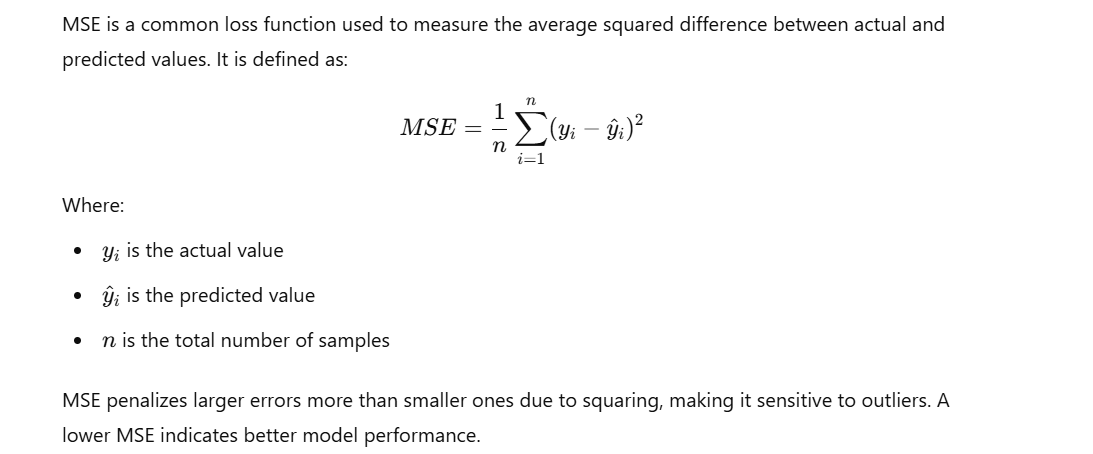
---

### **Quadratic Weighted Kappa (QWK)**  
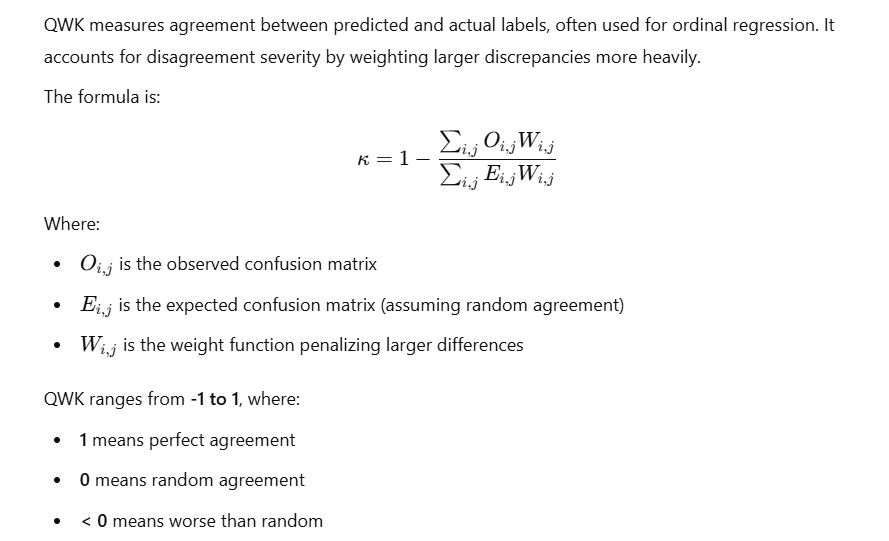

##**R2**
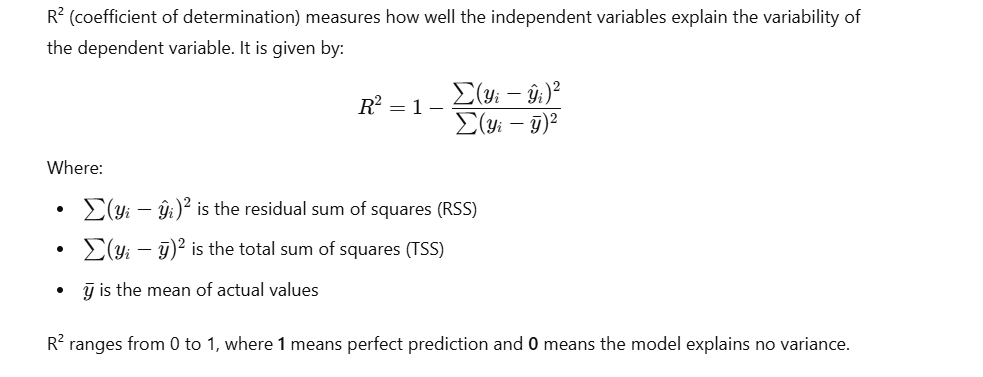

                                Model     MSE  R² Score  QWK Score
0      Linear Regression+WordtoVec+FE  4.4133    0.5036     0.6734
1                XGBoost+WordtoVec+FE  2.4867    0.7200     0.8346
2               CatBoost+WordtoVec+FE  2.4846    0.7204     0.8325
3                    SVR+WordtoVec+FE  2.8552    0.6783     0.7977
4               LightGBM+WordtoVec+FE  2.3491    0.7355     0.8433
5          Linear Regression+TFIDF+FE  5.4707    0.3833     0.6860
6                   XGBBoost+TFIDF+FE  2.4257    0.7270     0.8351
7                   CatBoost+TFIDF+FE  2.5741    0.7100     0.8195
8   Support Vector Regressor+TFIDF+FE  5.0034    0.4367     0.5620
9              LGBMRegressor+TFIDF+FE  2.3491    0.7355     0.8433
10               Linear Regression+FE  5.6051    0.3687     0.5391
11                         XGBoost+FE  4.0324    0.5457     0.7116
12                        CatBoost+FE  3.8123    0.5704     0.7216
13                             SVR+FE  3.8647    0.5644     0.

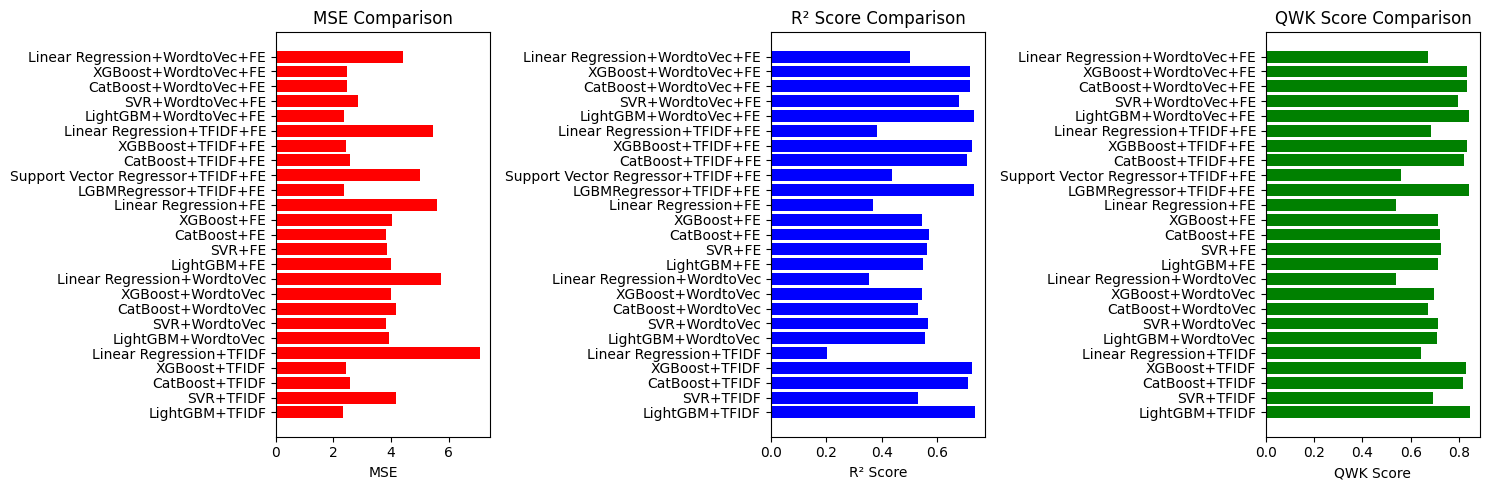

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt

models = [
    "Linear Regression+WordtoVec+FE", "XGBoost+WordtoVec+FE", "CatBoost+WordtoVec+FE", "SVR+WordtoVec+FE", "LightGBM+WordtoVec+FE",
    "Linear Regression+TFIDF+FE", "XGBBoost+TFIDF+FE", "CatBoost+TFIDF+FE", "Support Vector Regressor+TFIDF+FE", "LGBMRegressor+TFIDF+FE",
    "Linear Regression+FE", "XGBoost+FE", "CatBoost+FE", "SVR+FE", "LightGBM+FE",
    "Linear Regression+WordtoVec", "XGBoost+WordtoVec", "CatBoost+WordtoVec", "SVR+WordtoVec", "LightGBM+WordtoVec",
    "Linear Regression+TFIDF", "XGBoost+TFIDF", "CatBoost+TFIDF", "SVR+TFIDF", "LightGBM+TFIDF"
]

mse = [
    4.4133, 2.4867, 2.4846, 2.8552, 2.3491,
    5.4707, 2.4257, 2.5741, 5.0034, 2.3491,
    5.6051, 4.0324, 3.8123, 3.8647, 4.0047,
    5.7211, 4.0142, 4.1685, 3.8385, 3.9207,
    7.0813, 2.4433, 2.5702, 4.1605, 2.3388
]

r2 = [
    0.5036, 0.7200, 0.7204, 0.6783, 0.7355,
    0.3833, 0.7270, 0.7100, 0.4367, 0.7355,
    0.3687, 0.5457, 0.5704, 0.5644, 0.5488,
    0.3558, 0.5476, 0.5303, 0.5677, 0.5584,
    0.2012, 0.7250, 0.7106, 0.5313, 0.7367
]

qwk = [
    0.6734, 0.8346, 0.8325, 0.7977, 0.8433,
    0.6860, 0.8351, 0.8195, 0.5620, 0.8433,
    0.5391, 0.7116, 0.7216, 0.7267, 0.7144,
    0.5387, 0.6981, 0.6726, 0.7118, 0.7091,
    0.6436, 0.8309, 0.8189, 0.6906, 0.8451
]

# Create DataFrame
df2 = pd.DataFrame({"Model": models, "MSE": mse, "R² Score": r2, "QWK Score": qwk})
print(df2)

# Best Model Evaluation
best_model_index = mse.index(min(mse))
best_model = models[best_model_index]
best_mse = mse[best_model_index]
best_r2 = r2[best_model_index]
best_qwk = qwk[best_model_index]

best_model_summary = f"Based on the evaluation metrics, **{best_model}** performed the best, achieving the lowest MSE ({best_mse}), the highest R² Score ({best_r2}), and the highest QWK Score ({best_qwk}). This indicates that the combination of {best_model} provides the most accurate and reliable predictions for automated grading."
print(best_model_summary)

# Plot
fig, ax = plt.subplots(1, 3, figsize=(15, 5))

ax[0].barh(models, mse, color='red')
ax[0].set_title("MSE Comparison")
ax[0].invert_yaxis()
ax[0].set_xlabel("MSE")

ax[1].barh(models, r2, color='blue')
ax[1].set_title("R² Score Comparison")
ax[1].invert_yaxis()
ax[1].set_xlabel("R² Score")

ax[2].barh(models, qwk, color='green')
ax[2].set_title("QWK Score Comparison")
ax[2].invert_yaxis()
ax[2].set_xlabel("QWK Score")

plt.tight_layout()
plt.show()


# Saving Best model

In [ ]:
import joblib
joblib.dump(tfidf_vectorizer, "tfidf_vectorizer.pkl")
joblib.dump(model, "lightgbm_model.pkl")

['lightgbm_model.pkl']

In [ ]:
import joblib
model = joblib.load("lightgbm_model.pkl")
tfidf_vectorizer = joblib.load("tfidf_vectorizer.pkl")
def predict_essay_score(essay_text):

    processed_essay = dataPreprocessing(essay_text)
    essay_tfidf = tfidf_vectorizer.transform([processed_essay]).toarray()
    predicted_score = model.predict(essay_tfidf)
    print(f"\nPredicted Score: {np.round(predicted_score)[0]}")


essay_text = """
Education has always been a dynamic field, evolving with technological advancements.
In recent years, Artificial Intelligence (AI) has significantly transformed the way
students learn and teachers instruct. AI-powered tools, such as intelligent tutoring
systems, personalized learning platforms, and automated grading systems, are making
education more accessible, efficient, and tailored to individual needs.

One of the greatest advantages of AI in education is personalized learning.
Traditional classroom settings often struggle to cater to individual learning styles,
but AI-driven platforms analyze student performance and adapt the curriculum accordingly.
This ensures that students receive material suited to their learning pace, making education
more effective.

Additionally, AI helps educators by automating administrative tasks like grading and
attendance tracking. Automated essay scoring systems, for example, save teachers time
and provide students with instant feedback. Moreover, AI-powered chatbots assist students
in answering academic queries, ensuring 24/7 support for learning.

Despite its benefits, AI in education also raises concerns about over-reliance on
technology and data privacy. It is crucial to implement AI responsibly, ensuring that
it complements, rather than replaces, traditional teaching methods.

In conclusion, AI has immense potential to revolutionize education by making it more
personalized and efficient. However, a balanced approach, integrating AI with human
interaction, is essential for the best educational outcomes.
"""

predict_essay_score(essay_text)



Predicted Score: 5.0


/usr/local/lib/python3.11/dist-packages/lightgbm/sklearn.py:1007: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.
  X = _LGBMCheckArray(X, accept_sparse=True, force_all_finite=False)


# **Conclusion**
Automated Feedback and Grading Generation based on Machine Learning models can effectively streamline the grading process, providing an economical and scalable option for schools and platforms. The following solutions can be used:

Machine Learning algorithms such as XGBoost, CatBoost, and LightGBM can be useful for structured data and feature-based prediction, making them ideal for grading and feedback generation.

By leveraging machine learning for prediction and evaluation, we can design an automatic grading and feedback system that is both accurate and efficient. This system can minimize the grading burden of instructors and offer instant, personalized feedback to students, enabling them to enhance performance.

### **Best Performing Model**

Based on the evaluation metrics, **LGBMRegressor+TFIDF** performed the best, achieving the lowest MSE (2.2389), the highest R² Score (0.7367), and the highest QWK Score (0.8451). This indicates that the TF-IDF representation combined with LGBMRegressor provides the most accurate and reliable predictions for automated grading.